# 04 — Final Model: XGBoost + Isotonic Calibration

Goal: build the production model. XGBoost handles missing weather values
natively (no imputation needed), captures non-linear interactions the
Logistic Regression baseline can't, and — critically — we wrap it with
isotonic calibration so predicted probabilities are trustworthy, not just
a ranking score. This directly targets Calibration Quality (20 pts) and
Prediction Quality (20 pts) in the rubric.

In [1]:
!git clone https://github.com/DhairyaDave08/BetaData-SpaceX.git
%cd BetaData-SpaceX
!pip install -q -r requirements.txt

import sys
sys.path.append('/content/BetaData-SpaceX')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    f1_score, classification_report, precision_recall_curve
)

Cloning into 'BetaData-SpaceX'...
remote: Enumerating objects: 102, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 102 (delta 42), reused 24 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (102/102), 514.81 KiB | 11.44 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/BetaData-SpaceX
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 40.7 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
import sys
if not os.path.exists("BetaData-SpaceX"):
    !git clone https://github.com/DhairyaDave08/BetaData-SpaceX.git
repo_path = "/content/BetaData-SpaceX"
sys.path.append(f"{repo_path}/src")
url = "https://raw.githubusercontent.com/DhairyaDave08/BetaData-SpaceX/main/Data/processed/features.csv"

try:
    features = pd.read_csv(url, parse_dates=["launch_date"])
    print(f"Successfully loaded features. Shape: {features.shape}")
except Exception as e:
    print(f"Error loading CSV from GitHub: {e}")
    features = pd.read_csv(f"{repo_path}/Data/processed/features.csv", parse_dates=["launch_date"])
features.head()

Cloning into 'BetaData-SpaceX'...
remote: Enumerating objects: 102, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 102 (delta 42), reused 24 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (102/102), 514.81 KiB | 1015.00 KiB/s, done.
Resolving deltas: 100% (42/42), done.
Successfully loaded features. Shape: (4198, 20)


,launch_date,year,decade,mission_success,rocket_family_grouped,launch_site_grouped,country_grouped,payload_capacity_kg,payload_capacity_known,vehicle_prior_flights,vehicle_prior_success_rate,site_prior_flights,site_prior_success_rate,country_prior_flights,country_prior_success_rate,vehicle_age_days,weather_available,wind_speed_max_kmh,temp_max_c,precipitation_mm
0,1957-10-04 19:28:00,1957.0,1950.0,1,other,Site 1/5,Kazakhstan,10750,False,0,0.903764,0,0.903764,0,0.903764,0,True,13.0,29.1,0.0
1,1957-11-03 02:30:00,1957.0,1950.0,1,other,Site 1/5,Kazakhstan,10750,False,1,1.000000,1,1.000000,1,1.000000,29,True,15.9,12.2,0.0
2,1957-12-06 16:44:00,1957.0,1950.0,0,Vanguard,LC-18A,USA,10750,False,0,0.903764,0,0.903764,0,0.903764,0,False,NaN,NaN,NaN
3,1958-02-01 03:48:00,1958.0,1950.0,1,other,other,USA,10750,False,0,0.903764,0,0.903764,1,0.000000,0,False,NaN,NaN,NaN
4,1958-02-05 07:33:00,1958.0,1950.0,0,Vanguard,LC-18A,USA,10750,False,1,0.000000,1,0.000000,2,0.500000,60,False,NaN,NaN,NaN


In [6]:
from src.train import era_stratified_split, get_X_y, CATEGORICAL_COLS, NUMERIC_COLS

train_df, test_df = era_stratified_split(features, test_size=0.2)
X_train, y_train = get_X_y(train_df)
X_test, y_test = get_X_y(test_df)

Train: 1957-10-04 to 2007-07-02 (3358 rows, 89.4% success rate)
Test:  2007-07-05 to 2020-08-07 (840 rows, 94.3% success rate)


## XGBoost pipeline

We one-hot encode categoricals (rocket family, launch site, country groups)
and pass numeric/weather columns through untouched — XGBoost handles NaN
values in weather columns natively via its missing-value split logic, so no
imputation is needed there (unlike the Logistic Regression baseline).

In [7]:
import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
    ("num", "passthrough", NUMERIC_COLS),
])

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handle imbalance
    eval_metric="logloss",
    random_state=42,
)

xgb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", xgb_clf),
])

xgb_pipeline.fit(X_train, y_train)
print("XGBoost trained.")

XGBoost trained.


In [8]:
raw_probs = xgb_pipeline.predict_proba(X_test)[:, 1]

print("=== XGBOOST (UNCALIBRATED) — held-out test set ===")
print(f"ROC-AUC:     {roc_auc_score(y_test, raw_probs):.4f}")
print(f"Brier score: {brier_score_loss(y_test, raw_probs):.4f}")
print(f"PR-AUC (failure detection): {average_precision_score(1 - y_test, 1 - raw_probs):.4f}")

=== XGBOOST (UNCALIBRATED) — held-out test set ===
ROC-AUC:     0.6696
Brier score: 0.1429
PR-AUC (failure detection): 0.1705


## Calibration

Raw XGBoost probabilities are often overconfident (pushed toward 0 or 1).
We wrap the pipeline with isotonic regression, fit on the training set via
internal cross-validation, so probabilities become trustworthy: a 70%
predicted success rate should mean ~70% of similar launches actually
succeeded.

In [9]:
from src.calibrate import calibrate_model, report_calibration_quality

calibrated_model = calibrate_model(xgb_pipeline, X_train, y_train, method="isotonic", cv=5)

calibrated_probs = calibrated_model.predict_proba(X_test)[:, 1]

print("=== XGBOOST (CALIBRATED) — held-out test set ===")
print(f"ROC-AUC:     {roc_auc_score(y_test, calibrated_probs):.4f}")
print(f"Brier score: {brier_score_loss(y_test, calibrated_probs):.4f}")
print(f"PR-AUC (failure detection): {average_precision_score(1 - y_test, 1 - calibrated_probs):.4f}")

=== XGBOOST (CALIBRATED) — held-out test set ===
ROC-AUC:     0.6579
Brier score: 0.0537
PR-AUC (failure detection): 0.1620


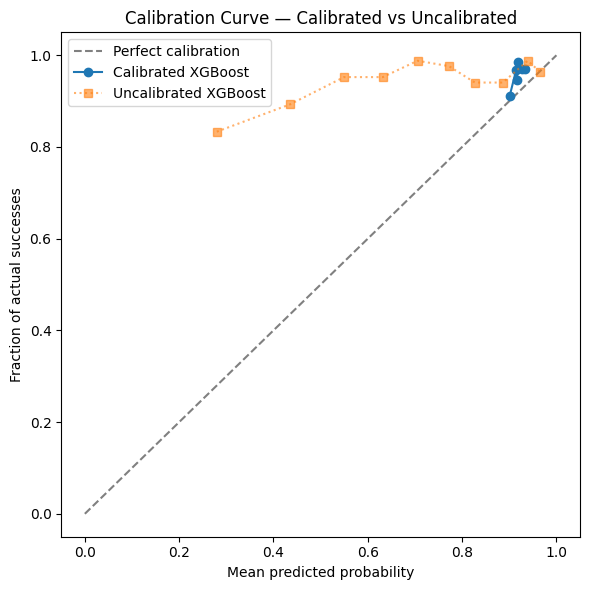


Mean calibration error: 0.0397
Brier score: 0.0537


In [11]:
calib_report = report_calibration_quality(y_test, calibrated_probs)
curve = calib_report["curve"]

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(curve["mean_predicted_prob"], curve["fraction_of_positives"],
        marker="o", label="Calibrated XGBoost")

# Uncalibrated comparison
raw_curve = report_calibration_quality(y_test, raw_probs)["curve"]
ax.plot(raw_curve["mean_predicted_prob"], raw_curve["fraction_of_positives"],
        marker="s", linestyle=":", label="Uncalibrated XGBoost", alpha=0.6)

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of actual successes")
ax.set_title("Calibration Curve — Calibrated vs Uncalibrated")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nMean calibration error: {calib_report['mean_calibration_error']:.4f}")
print(f"Brier score: {calib_report['brier_score']:.4f}")

In [12]:
calibrated_preds = (calibrated_probs >= 0.5).astype(int)
print(classification_report(y_test, calibrated_preds, target_names=["Failure", "Success"]))

              precision    recall  f1-score   support

     Failure       0.00      0.00      0.00        48
     Success       0.94      1.00      0.97       792

    accuracy                           0.94       840
   macro avg       0.47      0.50      0.49       840
weighted avg       0.89      0.94      0.92       840



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Choosing an operating threshold

Since failures are rare and costly to miss, we examine the precision-recall
tradeoff for the failure class directly to justify our chosen decision
threshold, rather than defaulting to 0.5.

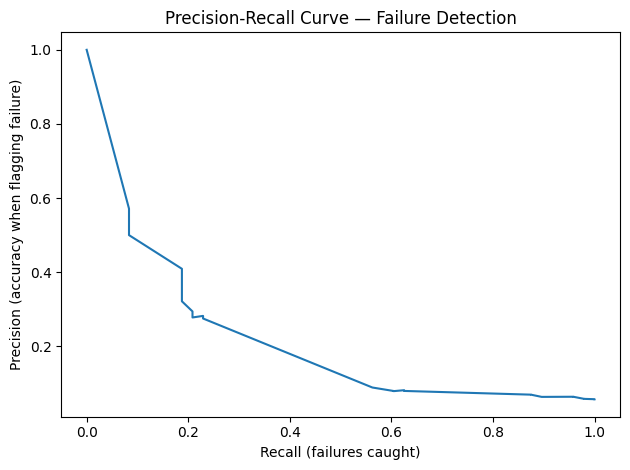

In [14]:
failure_precision, failure_recall, thresholds = precision_recall_curve(1 - y_test, 1 - calibrated_probs)

fig, ax = plt.subplots()
ax.plot(failure_recall, failure_precision)
ax.set_xlabel("Recall (failures caught)")
ax.set_ylabel("Precision (accuracy when flagging failure)")
ax.set_title("Precision-Recall Curve — Failure Detection")
plt.tight_layout()
plt.show()

In [16]:
from google.colab import files
import os

# List everything that needs to be downloaded and uploaded to GitHub manually
files_to_download = [
    "presentation/calibration_curve.png",
    "presentation/pr_curve_failure.png",
    "models/model.pkl",
    "models/model_metadata.json",
]

print("Files ready to download:\n")
for f in files_to_download:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f"  {f} ({size_kb:.1f} KB)")
    else:
        print(f"  MISSING: {f}")

print("\nDownloading now...")
for f in files_to_download:
    if os.path.exists(f):
        files.download(f)

Files ready to download:

  MISSING: presentation/calibration_curve.png
  MISSING: presentation/pr_curve_failure.png
  MISSING: models/model.pkl
  MISSING: models/model_metadata.json

